# Practice 04 - Agent의 병렬구조

## Todo - `create_agent()` 로 agent 3개 만들기
우선 각자 다른 3개의 Agent 를 만들고 테스트 해 보도록 합니다.

```py
user_prompt = '새로운 스마트 안경을 만들고 싶어.'
```
### 자료조사 Agent
#### 사용 Tool
- Tavily Search
- 추가로 원하는 Tool 붙이기 가능
#### 예시코드
```py
research_agent = create_agent(
    ...
)
research_result = research_agent.invoke(user_prompt)['messages'][-1]
```

### 디자이너 Agent
#### 사용 Tool
- Tavily Search
- 추가로 원하는 Tool 붙이기 가능
#### 예시코드
```py
design_agent = create_agent(
    ...
)
design_result = design_agent.invoke(user_prompt)['messages'][-1]
```

### PM Agent
#### 사용 Tool
- 없음
- 모델을 gpt-5로 사용해보기
#### 예시코드
```py
pm_agent = create_agent()
report = pm_agent.invoke(
    f'''요청 주문: {user_prompt}
    ---
    자료조사 : {research_result}
    ---
    디자인 결정 : {design_result}
    '''
)['messages'][-1]

print(report)
```

In [41]:
import os
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.tools import tool
from tavily import TavilyClient #tavily search 를 위한 프레임워크

load_dotenv()

user_prompt = '새로운 스마트 안경을 만들고 싶어'

In [34]:
@tool
def use_tavily(prompt:str):
  '''tavily에서 검색을 하기위한 tool'''
  tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))
  res = tavily_client.search(prompt)
  return res

In [35]:
# 자료조사 Agent
RESEARCH_SYS_PROMPT = '''당신은 10년 차 시니어 시장 분석가입니다.
사용자가 제시한 [프로젝트 주제]에 대해 다음 세 가지를 반드시 포함하여 리포트를 작성하세요.

현재 시장 트렌드 및 수요 분석

예상 타겟 고객층 (연령, 직업, 특징)

잠재적 경쟁사 또는 유사 서비스의 장단점
사실에 기반한 논조로, 불필요한 서론 없이 핵심만 요약해 주세요.'''

#Agent
research_agent = create_agent(
  model='openai:gpt-4.1-mini',
  tools=[use_tavily],
  system_prompt=RESEARCH_SYS_PROMPT,
)

research_result = research_agent.invoke({'messages':user_prompt})


In [36]:
# 디자이너 Agent
DESIGN_SYS_PROMPT = '''당신은 트렌드를 선도하는 Product 크리에이티브 디렉터입니다.
사용자가 제시한 [프로젝트 주제]를 바탕으로 서비스의 시각적 컨셉을 기획하세요.
다음 항목을 반드시 포함해야 합니다.

핵심 디자인 키워드 3가지 (예: 미니멀, 레트로, 신뢰감 등)
핵심 유저 인터페이스(UI) 포인트 2가지

개발자와 기획자가 바로 상상할 수 있도록 구체적이고 감각적으로 묘사하세요.'''

design_agent = create_agent(
  model='openai:gpt-4.1-mini',
  tools=[use_tavily],
  system_prompt=DESIGN_SYS_PROMPT,
)

design_result = design_agent.invoke({'messages':user_prompt})

In [40]:
design_result['messages'][-1].content

'[프로젝트 주제] 새로운 스마트 안경\n\n핵심 디자인 키워드 3가지:\n1. 미래지향적 (Futuristic) – 첨단 기술 느낌을 살린 세련된 메탈릭 소재와 투명한 디스플레이 적용\n2. 심플 & 모던 (Simple & Modern) – 불필요한 요소를 최대한 제거해 깔끔하고 누구나 부담 없이 착용 가능한 디자인\n3. 편안함과 경량감 (Comfort & Lightweight) – 장시간 착용에도 부담 없도록 가벼운 티타늄 프레임과 인체공학적 곡선 적용\n\n핵심 UI 포인트 2가지:\n1. 직관적인 제스처 인터페이스 – 안경 다리 부분에 터치 및 슬라이드 감지센서를 넣어 손가락 제스처만으로 메뉴 이동, 확대·축소, 선택이 가능하며 물리 버튼 최소화\n2. AR 기반 실시간 정보 오버레이 – 시야에 자연스럽게 녹아드는 3D AR HUD를 통해 날씨, 일정, 내비게이션, 건강 데이터 등이 투명하게 표시되고 사용자가 시선을 옮길 때마다 그에 맞는 컨텍스트 정보를 자동 업데이트\n\n설명:\n이 스마트 안경은 디자인에서 미래지향적인 메탈릭 텍스처와 투명 디스플레이가 융합되어 첨단기술 이미지를 극대화하고, 미니멀하고 깔끔한 라인으로 일상생활에서 부담 없이 사용할 수 있게 설계됩니다. 착용감 향상을 위해 티타늄 소재와 인체공학적 프레임 곡선으로 경량화 및 편안함에 집중했습니다.\n\nUI는 터치 다리부분에서 이루어지는 직관적인 제스처 조작으로 사용자가 쉽게 조절 가능하며, HUD를 통해 실시간으로 필요한 정보를 자연스럽게 눈앞에 띄워 몰입감과 편리함을 극대화합니다. 이런 조합은 스마트 안경이 단순한 기기를 넘어 패션과 기술의 경계를 허무는 새로운 라이프스타일 액세서리가 되도록 합니다.'

In [53]:
# PM Agent
PM_SYS_PROMPT = '''당신은 프로젝트를 총괄하는 헤드 PM(Product Manager)입니다.
아래 제공된 자료조사 리포트와 디자인 방향성을 종합하여 최종 '원페이지 기획서(1-Page PRD)'를 작성하세요.

기획서는 다음 구조를 따르세요:

서비스 한 줄 소개

타겟 고객 및 해결하려는 문제 (자료조사 바탕)

핵심 기능 및 시각적 컨셉 (디자인 방향성 바탕)

다음 액션 플랜 (PM의 관점에서 제안)

'''
pm_agent = create_agent(
  model='openai:gpt-5',
  tools=[],
  system_prompt=PM_SYS_PROMPT,
)

pm_result = pm_agent.invoke({
  'messages': f'''요청 주문: {user_prompt}
    ---
    자료조사 : {research_result['messages'][-1].content}
    ---
    디자인 결정 : {design_result['messages'][-1].content}
    '''
})


In [44]:
pm_result['messages'][-1].content
print(pm_result['messages'][-1].content)

서비스 한 줄 소개
- 손을 쓰지 않고 필요한 정보만 눈앞에 띄우는, 초경량·프라이버시 중심의 AI AR 스마트 안경

타겟 고객 및 해결하려는 문제 (자료조사 바탕)
- 핵심 타겟: 20–40대 기술 친화적 직장인·크리에이터·현장 업무자·피트니스 애호가
- 고객 과업(JTBD)과 문제
  - 이동 중 일정/메시지/길안내를 빠르게 확인하고 싶지만, 스마트폰 확인이 번거롭고 주의가 분산됨
  - 회의·현장 작업에서 손이 바빠 정보·절차서를 즉시 보기 어렵고, 원격 지원 연계가 불편함
  - 웨어러블은 무겁고 배터리가 짧아 종일 사용이 어려우며, 카메라·마이크로 인한 프라이버시 우려가 큼
  - 고가·복잡한 XR 기기는 일상 사용에 과하고, 소비자 친화적 제품은 기능/생태계가 제한적
- 해결 방향
  - 글랜스형 AR HUD로 “필요한 순간, 필요한 정보만” 제공해 몰입·안전 유지
  - 초경량·인체공학 설계와 실사용 1일 범위의 배터리로 종일 착용 가능
  - 온디바이스 처리·하드웨어 프라이버시 제어로 신뢰 확보
  - 소비자/엔터프라이즈 모두 활용 가능한 개방형 생태계와 합리적 가격대

핵심 기능 및 시각적 컨셉 (디자인 방향성 바탕)
- 디자인 키워드
  - 미래지향적: 메탈릭 텍스처 + 투명 웨이브가이드 디스플레이, 절제된 라인
  - 심플 & 모던: 물리 버튼 최소화, 미니멀 디테일, 도심/비즈니스/캐주얼 모두 어울림
  - 편안함·경량: 티타늄 프레임(목표 34–38g), 인체공학 곡선, 장시간 착용
- 입력·인터랙션
  - 직관 제스처: 안경 다리(템플) 터치/슬라이드/탭으로 메뉴 이동·확대/축소·선택
  - 보조 입력: 조용한 음성 명령, 시선·머리 방향 기반 포커스(컨텍스트 전환), 물리 긴급 Mute 스위치
- AR HUD·AI
  - 3D 오버레이 카드: 시간/날씨/일정/메시지 요약/내비/건강 데이터, 시야 전환 시 컨텍스트 자동 업데이트
  - 글랜스 우선·세션 보조: 평소 최소 정보, 필요 시 확장 보기로 전환(주의 분산 최소화)
  - A

## 위의 에이전트들을 병렬형태로 Graph화

In [109]:
from langgraph.graph import MessagesState, START, END, StateGraph

class TeamState(MessagesState):
    research:str
    design:str

def research_node(state:TeamState):
    result = research_agent.invoke({
        'messages':state['messages']
    })
    return{'research':result['messages'][-1].content}

def design_node(state:TeamState):
    result = design_agent.invoke({
        'messages':state['messages']
    })
    return{'design':result['messages'][-1].content}

def pm_node(state:TeamState):
    pm_prompt = f'''요청 주문: {state["messages"][-1].content}
    ---
    자료조사 : {state['research']}
    ---
    디자인 결정 : {state['design']}
    '''
    result = pm_agent.invoke({
        'messages': pm_prompt
    })
    
    return{'messages':result['messages'][-1]}

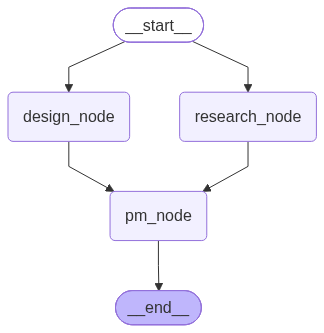

In [97]:
builder = StateGraph(TeamState)

builder.add_node('research_node',research_node)
builder.add_node('design_node',design_node)
builder.add_node('pm_node',pm_node)

builder.add_edge(START,'research_node')
builder.add_edge(START,'design_node')
builder.add_edge('research_node','pm_node')
builder.add_edge('design_node','pm_node')
builder.add_edge('pm_node', END)

graph = builder.compile()
graph


In [98]:
res = graph.invoke({
  'messages':'스마트 안경 기획하자'
})

In [108]:
print(res['messages'][-2])

content='요청 주문: 스마트 안경 기획하자\n    ---\n    자료조사 : 스마트 안경 시장 분석 리포트\n\n1. 현재 시장 트렌드 및 수요 분석\n- 스마트 안경 시장은 AI 및 ML 기술 통합, 경량화·세련된 디자인 개발, 고급 센서 도입 등으로 빠르게 성장 중입니다.\n- 증강현실(AR) 및 가상현실(VR) 기술과 결합하여 의료, 스포츠, 물류, 제조, 원격지원 등 다양한 산업 분야에서 핸즈프리 작업 도구로 활용도가 높아지고 있습니다.\n- 2024년부터 2030년까지 연간 복합성장률(CAGR) 약 18.9%~24%에 달하는 고성장 구간에 있으며, 시장 규모는 2022년 약 20억 달러에서 2034년 550~650억 달러까지 확대될 전망입니다.\n- 주요 성장 동인은 실시간 데이터 접근성 향상, AI 기반 개인 맞춤형 기능, 패션과 일상용으로서의 착용 편의성 증가, 가격 하락과 배터리 성능 개선 등입니다.\n- 메타, 삼성전자, 에실로룩소티카, 레이네오 등 글로벌 대기업들이 경쟁하며 기술 발전과 가격 경쟁 심화가 예상됩니다.\n\n2. 예상 타겟 고객층\n- 연령: 20~50대 초중반\n- 직업: IT 및 기술분야 전문가, 제조·물류·의료 현장 작업자, 스포츠 및 아웃도어 활동가, 일반 소비자 중 패션과 실용성을 추구하는 젊은 층부터 중장년층까지\n- 특징: 최신 IT 기기에 친숙하며 핸즈프리 작업과 실시간 정보 이용을 선호하고, AI 기능과 실용성을 중시함. 패션·라이프스타일 아이템으로서 디자인과 착용감에 민감한 소비자도 포함됨.\n\n3. 잠재적 경쟁사 및 유사 서비스 장단점\n- 메타\n  장점: AI 기술력 우위, 글로벌 브랜드 에실로룩소티카 협업, 다양한 AI 기능(실시간 번역, 음성 인식), 시장 점유율 1위(69.2%)\n  단점: 초기 고가 제품 중심, 일부 소비자 프라이버시 우려\n- 삼성전자\n  장점: 젠틀몬스터, 워비파커 등 유명 브랜드와 협업해 세련된 디자인 제공, AI 기반 길 안내 및 번역 기능 강화, 가격 경쟁력